# <img style="float: left; padding-right: 10px; width: 45px" src="https://raw.githubusercontent.com/Harvard-IACS/2018-CS109A/master/content/styles/iacs.png"> Data Science 2: Advanced Topics in Data Science 
## Homework 2: Convolutional Neural Networks

**Harvard University**\
**Spring 2026**\
**Instructors**: Pavlos Protopapas & Kevin Rader

<hr style="height:2pt">

In [1]:
import os
import time
import math
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, Subset, random_split

import torchvision
from torchvision import transforms
from torchvision.transforms import functional as tvF

from tqdm import tqdm

# Reproducibility
SEED = 1090
def set_seed(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    # Deterministic runs are slower; enable if you need exact reproducibility
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)
print("device:", DEVICE)

torch: 2.10.0
torchvision: 0.25.0
device: cuda


In [2]:
# Helper utilities (provided)
# These are small, readable helpers to keep dataset + DataLoader setup consistent.

# Prefer using a shared, pre-downloaded dataset directory on the course cluster when available.
# If you run this notebook elsewhere, it will fall back to a local ./data directory and download as needed.
SHARED_DATA_ROOT = Path("/shared/courseSharedFolders/163602outer/163602/datasets")
LOCAL_DATA_ROOT  = Path("data")

def shared_or_local(check_path: Path, *, shared_dir: Path = SHARED_DATA_ROOT, local_dir: Path = LOCAL_DATA_ROOT):
    """Pick (root, download) for torchvision datasets.

    If `shared_dir/check_path` exists, we assume the dataset is already present and set download=False.
    Otherwise we use `local_dir` and set download=True only if `local_dir/check_path` is missing.
    """
    if (shared_dir / check_path).exists():
        return shared_dir, False
    return local_dir, not (local_dir / check_path).exists()


def subset_random(ds, n: int, seed: int):
    """Deterministically choose a random subset (without replacement)."""
    n = min(int(n), len(ds))
    rng = np.random.RandomState(seed)
    idx = rng.choice(len(ds), size=n, replace=False)
    return torch.utils.data.Subset(ds, idx)

def split_train_val(ds, val_size: int, seed: int):
    """Deterministic train/val split using torch.utils.data.random_split."""
    val_size = int(val_size)
    train_size = len(ds) - val_size
    if train_size <= 0:
        raise ValueError("val_size must be smaller than the dataset size.")
    g = torch.Generator().manual_seed(seed)
    return random_split(ds, [train_size, val_size], generator=g)

# Multiprocessing in Jupyter can be finicky (especially on macOS/Windows).
# Default to 0 workers for reliability. On Linux, you can bump this to 2–4 for speed.
NUM_WORKERS = 0

def make_loaders(train_ds, val_ds, test_ds, batch_size: int, *, device: torch.device, num_workers: int = NUM_WORKERS):
    """Standard train/val/test DataLoaders with sensible defaults."""
    pin = (device.type == "cuda")
    common = dict(
        batch_size=int(batch_size),
        num_workers=int(num_workers),
        pin_memory=pin,
        persistent_workers=(num_workers > 0),
    )
    train_loader = DataLoader(train_ds, shuffle=True, **common)
    val_loader   = DataLoader(val_ds,   shuffle=False, **common)
    test_loader  = DataLoader(test_ds,  shuffle=False, **common)
    return train_loader, val_loader, test_loader

class RotateAngleRegressionDataset(Dataset):
    """Wrap a PIL-image dataset to produce (rotated_image_tensor, angle_deg).

    - `base_ds[idx]` may return an Image or (Image, target). We use only the image.
    - `angles_deg[i]` should be a 1D array-like of degrees (float).
    """
    def __init__(self, base_ds, angles_deg, *, preprocess=None, normalize=None, fill=0):
        self.base_ds = base_ds
        self.angles = np.asarray(angles_deg, dtype=np.float32)
        if len(self.angles) != len(self.base_ds):
            raise ValueError("angles_deg must have the same length as base_ds.")
        self.preprocess = preprocess  # PIL -> PIL (e.g., crop/resize)
        self.to_tensor = transforms.ToTensor()
        self.normalize = normalize    # Tensor -> Tensor (e.g., Normalize)
        self.fill = fill

    def __len__(self):
        return len(self.base_ds)

    def __getitem__(self, idx):
        item = self.base_ds[idx]
        img = item[0] if isinstance(item, (tuple, list)) else item  # PIL Image
        if self.preprocess is not None:
            img = self.preprocess(img)

        angle = float(self.angles[idx])
        img = tvF.rotate(img, angle, interpolation=tvF.InterpolationMode.BILINEAR, fill=self.fill)

        x = self.to_tensor(img)
        if self.normalize is not None:
            x = self.normalize(x)

        y = torch.tensor(angle, dtype=torch.float32)
        return x, y


In [3]:
time_start = time.time()

<div style = "background: lightsalmon; border: thin solid black; border-radius: 2px; padding: 5px">

### Instructions
- To submit your notebook, follow the instructions given in on the Canvas assignment page.
- Plots should be legible and interpretable *without having to refer to the code that generated them*. They should includelabels for the $x$- and $y$-axes as well as a descriptive title and/or legend when appropriate.
- When asked to interpret a visualization, do not simply describe it (e.g., "the curve has a steep slope up"), but instead explain what you believe the plot *means*.
- Autograding tests are mostly to help you debug. The tests are not exhaustive so simply passing all tests may not be sufficient for full credit.
- The use of *extremely* inefficient or error-prone code (e.g., copy-pasting nearly identical commands rather than looping) may result in only partial credit.
- We have tried to include all the libraries you may need to do the assignment in the imports cell provided below. Please get course staff approval before importing any additional 3rd party libraries.
- Enable scrolling output on cells with very long output.
- Feel free to add additional code or markdown cells as needed.
- Ensure your code runs top to bottom without error and passes all tests by restarting the kernel and running all cells (note that this can take a few minutes). 
- **You should do a "Restart Kernel and Run All Cells" before submitting to ensure (1) your notebook actually runs and (2) all output is visible**
</div>

## About this Homework
In this homework, we will explore Convolutional Neural Networks (CNNs).

- In PART 1, we will begin by building a CNN to classify CIFAR-10 images. The low resolution of the dataset make it a smooth introduction to CNNs as we can get reasonable performance without huge models or long training times.

- Then, in PART 2, we will see that CNNs' impressive performance extends beyond just classifying images! They can serve as image input processing for a variety of tasks. This is demonstrated by training a network on the CelebA dataset to correct rotated images of faces to make them upright.

- Finally, in PART 3, we will look at a dataset of pet photos for image segmentation. This is a classification problem. But instead of assigning class probabilities to the image as a whole, we assign class probabilities for *each individual pixel*, identifying what regions of the image belong to each class (e.g., 'pet' or 'background'). 

**IMPORTANT NOTES:**

- Convolutional neural networks are computationally intensive.
- **We highly recommend that you train your model on a system using GPUs. For this, we recommend using [the GPU-enabled Jupyter environment provided to you as part of this course](https://ood.huit.harvard.edu/pun/sys/dashboard/batch_connect/sys/ood-jupyterlab-spack-mamba/cs1090b-gpu/session_contexts/new).** 
- Models that take hours to train on CPUs can be trained in just minutes when using GPUs.
- **To avoid getting frustrated by having to re-train your models every time you run your notebook, you should save your trained model weights for later use.** Model histories can also be saved to disk with `pickle` and checked with an `if not` condition. This is a great way to check if the model weights exist before training, preventing redundant retraining. Please, think of the penguins! 🐧

**KERNEL CRASHES:**

If your kernel crashes as you attempt to train your model, please check the following items:
- Models with too many parameters might not fit in GPU memory. Try reducing the size of your model.
- A large batch size will attempt to load too many images in GPU memory. Avoid using a very large batch size.
- Avoid creating multiple copies of the data.

## PART 1: Building a Basic CNN Model

### Overview
In this question, you will use **PyTorch** to create a convolutional neural network for predicting the *type of object* shown in each image from the [CIFAR-10](https://pytorch.org/vision/stable/generated/torchvision.datasets.CIFAR10.html) dataset. CIFAR-10 contains 50,000 32×32 color training images and 10,000 test images, with 10 classes.

### 1.0 Loading & Preprocessing CIFAR-10
Here we load the CIFAR-10 dataset using `torchvision.datasets.CIFAR10`, converting the images tensors, make a train/val split, and create the train, val, and test DataLoaders for you. You may decide to modify parts of this code (e.g., the transforms) if you think it will improve model performance. Just be sure to justify any changes you make in a markdown cell.

In [4]:
# CIFAR-10 dataset (cached on the course cluster)

train_tf = transforms.ToTensor()
test_tf  = transforms.ToTensor()

CIFAR_CHECK = Path("cifar-10-batches-py/data_batch_1")
CIFAR_ROOT, cifar_download = shared_or_local(CIFAR_CHECK, local_dir=Path("data"))

train_full = torchvision.datasets.CIFAR10(
    root=CIFAR_ROOT, train=True, download=cifar_download, transform=train_tf
)
test_ds = torchvision.datasets.CIFAR10(
    root=CIFAR_ROOT, train=False, download=cifar_download, transform=test_tf
)

# Create a true validation split from the training set
VAL_SIZE = 5000
train_ds, val_ds = split_train_val(train_full, val_size=VAL_SIZE, seed=SEED)

BATCH_SIZE = 128 if DEVICE.type == "cuda" else 64
train_loader, val_loader, test_loader = make_loaders(
    train_ds, val_ds, test_ds,
    batch_size=BATCH_SIZE,
    device=DEVICE,
    num_workers=NUM_WORKERS
)

print("CIFAR root:", CIFAR_ROOT, "| download:", cifar_download)
print("Split sizes:", len(train_ds), len(val_ds), len(test_ds))

CIFAR root: /shared/courseSharedFolders/163602outer/163602/datasets | download: False
Split sizes: 45000 5000 10000


### 1.1 Constructing the Model

Construct a classification model architecture using a combination of the following layers: Conv2d, MaxPool2d, Linear, Dropout and a flatten operation. The layers don’t necessarily need to be in this order, and you can use as many of these types of layers as you’d like. 

 - You may choose to construct your own implementation of a well-known architecture like AlexNet or VGG16, or you can create an architecture of your own devising.

 - However, you MUST code the network yourself and not use a pre-written implementation. 

 - You must have multiple Conv2d layers.

 - You are also permitted to use BatchNorm2d and different types of pooling layers *provided that you explain what they are doing and why they are helpful to your architecture*.

<div style="background-color:#e6f2ff; padding:15px; border-radius:8px;">

The model is a CNN made of 3 convolutional blocks followed by a fully connected classifier. Each block contains two Conv2d layers with 3×3 kernels, followed by BatchNorm2d, ReLU, MaxPool2d, and Dropout.

The convolutional layers extract spatial features from the images. Stacking multiple conv layers allows the network to learn more complex patterns: the first layers detect simple features like edges, and deeper layers capture more abstract features. I used small 3×3 kernels because they are standard and work well for CIFAR-10.

BatchNorm2d normalizes the activations of each channel during training so that they have mean 0 and variance 1. This stabilizes gradients, speeds up convergence, and makes training more reliable. ReLU adds non-linearity so the model can learn complex relationships.

MaxPool2d reduces the spatial size of the feature maps, which lowers computation and helps the model focus on the most important features. Dropout is included to reduce overfitting, since CIFAR-10 is not a very large dataset.

Finally, the feature maps are flattened and passed through linear layers to produce the final 10 output scores, one for each class.

</div>

In [5]:
# Your code here

model_CNN_Cifar = nn.Sequential(
    # Input: (3, 32, 32)

    # Block 1 -> (64, 16, 16)
    nn.Conv2d(3, 64, kernel_size=3, padding=1),
    nn.BatchNorm2d(64),
    nn.ReLU(inplace=True),
    nn.Conv2d(64, 64, kernel_size=3, padding=1),
    nn.BatchNorm2d(64),
    nn.ReLU(inplace=True),
    nn.MaxPool2d(2),              # 32 -> 16
    nn.Dropout(0.30),

    # Block 2 -> (128, 8, 8)
    nn.Conv2d(64, 128, kernel_size=3, padding=1),
    nn.BatchNorm2d(128),
    nn.ReLU(inplace=True),
    nn.Conv2d(128, 128, kernel_size=3, padding=1),
    nn.BatchNorm2d(128),
    nn.ReLU(inplace=True),
    nn.MaxPool2d(2),              # 16 -> 8
    nn.Dropout(0.30),

    # Block 3 -> (256, 4, 4)
    nn.Conv2d(128, 256, kernel_size=3, padding=1),
    nn.BatchNorm2d(256),
    nn.ReLU(inplace=True),
    nn.Conv2d(256, 256, kernel_size=3, padding=1),
    nn.BatchNorm2d(256),
    nn.ReLU(inplace=True),
    nn.MaxPool2d(2),              # 8 -> 4
    nn.Dropout(0.30),

    # Classifier
    nn.Flatten(),                 # 256*4*4 = 4096
    nn.Linear(256 * 4 * 4, 512),
    nn.ReLU(inplace=True),
    nn.Dropout(0.50),
    nn.Linear(512, 10)            # logits for 10 classes
).to(DEVICE)

print(model_CNN_Cifar)

Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (5): ReLU(inplace=True)
  (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (7): Dropout(p=0.3, inplace=False)
  (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (10): ReLU(inplace=True)
  (11): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (12): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (13): ReLU(inplace=True)
  (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (15): Dropout(p=0.3, inplace=Fal

### 1.2 Model parameter growth
How does the number of total parameters change (e.g. linearly, exponentially, etc.) as the number of filters per layer increases? You can find this empirically by constructing multiple models with the same type of architecture and increasing the number of filters. Generate a plot showing the relationship and explain why it has this relationship. 

**HINT:** Completing this question is far easier if you write a function that generates your desired architecture in 1.1, with arguments that allow you to easily rebuild the architecture with varying numbers of filters per layer.

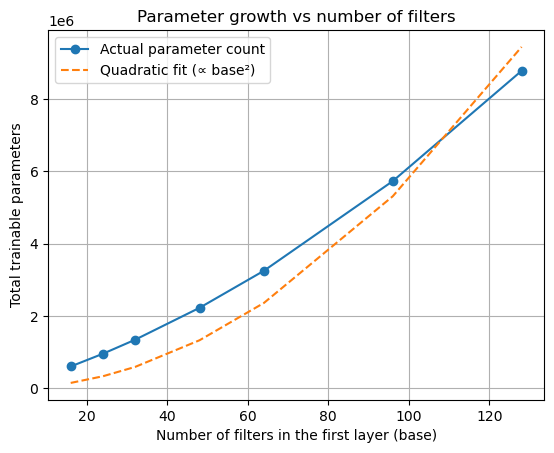

In [6]:
# Your code here

def architecture_cnn(base): #Same architecture as before, but width-controlled by `base` = number of filters in the first layer

    c1 = int(base)
    c2 = int(2 * base)
    c3 = int(4 * base)

    return nn.Sequential(
        # Block 1
        nn.Conv2d(3, c1, 3, padding=1),
        nn.BatchNorm2d(c1),
        nn.ReLU(inplace=True),
        nn.Conv2d(c1, c1, 3, padding=1),
        nn.BatchNorm2d(c1),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(2),
        nn.Dropout(0.30),

        # Block 2
        nn.Conv2d(c1, c2, 3, padding=1),
        nn.BatchNorm2d(c2),
        nn.ReLU(inplace=True),
        nn.Conv2d(c2, c2, 3, padding=1),
        nn.BatchNorm2d(c2),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(2),
        nn.Dropout(0.30),

        # Block 3
        nn.Conv2d(c2, c3, 3, padding=1),
        nn.BatchNorm2d(c3),
        nn.ReLU(inplace=True),
        nn.Conv2d(c3, c3, 3, padding=1),
        nn.BatchNorm2d(c3),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(2),
        nn.Dropout(0.30),

        # Classifier
        nn.Flatten(),
        nn.Linear(c3 * 4 * 4, 512),
        nn.ReLU(inplace=True),
        nn.Dropout(0.50),
        nn.Linear(512, 10),
    )

def count_parameters(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

bases = [16, 24, 32, 48, 64, 96, 128]
param_counts = []

for b in bases:
    m = architecture_cnn(base=b).to(DEVICE)
    param_counts.append(count_parameters(m))

# Fit a quadratic curve: a * base^2 by estimating 'a' using least squares
bases_np = np.array(bases)
params_np = np.array(param_counts)
a = np.sum(params_np * bases_np**2) / np.sum((bases_np**2)**2)
quadratic_fit = a * bases_np**2

# Plot
plt.figure()
plt.plot(bases, param_counts, marker="o", label="Actual parameter count")
plt.plot(bases, quadratic_fit, linestyle="--", label="Quadratic fit (∝ base²)")
plt.xlabel("Number of filters in the first layer (base)")
plt.ylabel("Total trainable parameters")
plt.title("Parameter growth vs number of filters")
plt.legend()
plt.grid(True)
plt.show()


**INTERPRETATION:**

<div style="background-color:#e6f2ff; padding:15px; border-radius:8px;">

When I increase the number of filters in each convolutional layer, the total number of parameters grows approximately quadratically. This happens because the number of parameters in a convolutional layer is proportional to  

$$
k^2 \cdot C_{in} \cdot C_{out}.
$$ where $k$ is the kernel size

If I scale the width of the network by a factor $s$ (for example doubling the base number of filters), then both the number of input channels $C_{in}$ and output channels $C_{out}$ in deeper layers increase by roughly $s$. As a result, the number of weights becomes proportional to  

$$
(s C_{in}) \cdot (s C_{out}) = s^2 \cdot C_{in} C_{out},
$$

so the parameter count grows like $s^2$.

Intuitively, increasing the number of filters does not just add more feature maps, it also increases the number of connections between feature maps across layers. Each additional filter in one layer must connect to all filters in the previous layer, so widening the network increases the number of connections multiplicatively rather than additively.

Although the fully connected layers grow more linearly with the final channel size, the convolutional layers contain most of the parameters, so the overall parameter growth appears approximately quadratic in the number of filters.

</div>

### 1.3 Choose a model, train and evaluate it

#### 1.3.1
Use the `summary` function on your chosen architecture to display its structure and the total number of parameters. Then train your model using the CIFAR-10 DataLoaders that were created earlier. You can choose to train your model for as long as you'd like, but you should aim for at least 10 epochs. Report your validation and test accuracies. You can achieve a test accuracy of over 75% in about 6 minutes of training.

**Hint:** It would be helpful to add code which either saves your model to a local directory if it is the first time you're training it or loads your model if a saved file version currently exists in that directory. This will not only help save time when you rerun your notebook, but it will also ensure reproducible results in the rest of Part 1.

In [7]:
def summarize(model: nn.Module, input_shape=(3, 32, 32)):
    """Print a minimal parameter + shape summary."""
    print(model)
    print(f"trainable params: {count_parameters(model):,}")
    device = next(model.parameters()).device  # model device (cpu or cuda)
    dummy = torch.zeros(1, *input_shape, device=device)
    with torch.no_grad():
        out = model(dummy)
    print("output shape:", tuple(out.shape))

In [8]:
# Specify model and display summary
# Your code here

# hyperparameters
base = 64
EPOCHS = 20
LR = 3e-4
WEIGHT_DECAY = 1e-4

SAVE_DIR = Path("saved_models")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH_CIFAR   = SAVE_DIR / f"model_CNN_Cifar_base{base}_ep{EPOCHS}_lr{LR}_wd{WEIGHT_DECAY}.pt"
HISTORY_PATH_CIFAR = SAVE_DIR / f"model_CNN_Cifar_base{base}_ep{EPOCHS}_lr{LR}_wd{WEIGHT_DECAY}_history.pt"

model = architecture_cnn(base=base).to(DEVICE)
summarize(model)

Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (5): ReLU(inplace=True)
  (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (7): Dropout(p=0.3, inplace=False)
  (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (10): ReLU(inplace=True)
  (11): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (12): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (13): ReLU(inplace=True)
  (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (15): Dropout(p=0.3, inplace=Fal

In [9]:
# Train cifar-10 model
# Evaluate trained model on the train, validation, and test set,
# reporting loss and accuracy for each.
# Your code here


def train_one_epoch_cifar(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total = 0

    for x, y in tqdm(loader, leave=False):
        x, y = x.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        bs = x.size(0)
        total_loss += loss.item() * bs
        total_correct += (logits.argmax(dim=1) == y).sum().item()
        total += bs

    return total_loss / total, total_correct / total

@torch.no_grad()
def evaluate_cifar(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total = 0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        loss = criterion(logits, y)

        bs = x.size(0)
        total_loss += loss.item() * bs
        total_correct += (logits.argmax(dim=1) == y).sum().item()
        total += bs

    return total_loss / total, total_correct / total


criterion = nn.CrossEntropyLoss() #loss function
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY) #opttmizer for CNNs


if MODEL_PATH_CIFAR.exists() and HISTORY_PATH_CIFAR.exists():
    print(f"Loading saved best weights from: {MODEL_PATH_CIFAR}")
    model.load_state_dict(torch.load(MODEL_PATH_CIFAR, map_location=DEVICE))
    history = torch.load(HISTORY_PATH_CIFAR)
    print("Loaded saved model and history.")
else:
    history = {
        "train_loss": [],
        "train_acc":  [],
        "val_loss":   [],
        "val_acc":    [],
    }

    best_val_acc = -1.0
    best_state = None

    for epoch in range(1, EPOCHS + 1):
        train_loss, train_acc = train_one_epoch_cifar(model, train_loader, criterion, optimizer)
        val_loss, val_acc     = evaluate_cifar(model, val_loader, criterion)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch:02d} | "
              f"train loss {train_loss:.4f} acc {train_acc:.4f} | "
              f"val loss {val_loss:.4f} acc {val_acc:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)

    torch.save(model.state_dict(), MODEL_PATH_CIFAR)
    torch.save(history, HISTORY_PATH_CIFAR)

    print("Training complete. Model and history saved.")


train_loss, train_acc = evaluate_cifar(model, train_loader, criterion)
val_loss, val_acc     = evaluate_cifar(model, val_loader, criterion)
test_loss, test_acc   = evaluate_cifar(model, test_loader, criterion)

print(f"TRAIN | loss {train_loss:.4f} | acc {train_acc:.4f}")
print(f"VAL   | loss {val_loss:.4f} | acc {val_acc:.4f}")
print(f"TEST  | loss {test_loss:.4f} | acc {test_acc:.4f}")

Loading saved best weights from: saved_models/model_CNN_Cifar_base64_ep20_lr0.0003_wd0.0001.pt
Loaded saved model and history.
TRAIN | loss 0.1580 | acc 0.9432
VAL   | loss 0.4534 | acc 0.8630
TEST  | loss 0.4828 | acc 0.8510


#### 1.3.2
Plot the training loss and accuracy per epoch (both train and validation) for your chosen architecture.

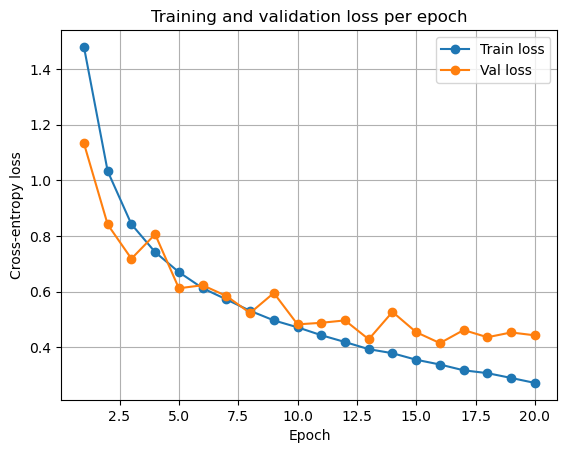

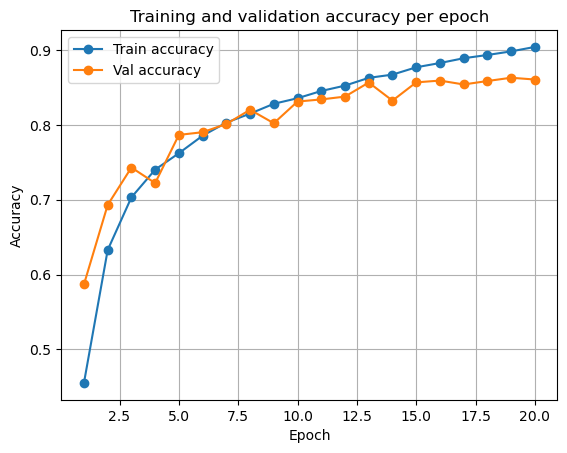

In [10]:
# Trace Plot of training history
# Your code here

epochs = np.arange(1, len(history["train_loss"]) + 1)

# Loss plot
plt.figure()
plt.plot(epochs, history["train_loss"], marker="o", label="Train loss")
plt.plot(epochs, history["val_loss"], marker="o", label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.title("Training and validation loss per epoch")
plt.legend()
plt.grid(True)
plt.show()

# Accuracy plot
plt.figure()
plt.plot(epochs, history["train_acc"], marker="o", label="Train accuracy")
plt.plot(epochs, history["val_acc"], marker="o", label="Val accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and validation accuracy per epoch")
plt.legend()
plt.grid(True)
plt.show()

<div style="background-color:#e6f2ff; padding:15px; border-radius:8px;">

The model learns quickly during the first few epochs, as shown by the rapid decrease in loss and increase in accuracy on both the training and validation sets. Around epoch 15, the model reaches a strong validation performance, with accuracy close to its maximum.

After that point, the training accuracy continues to increase, but the validation accuracy improves only slightly and mostly stabilizes. This suggests that the model keeps fitting the training data more closely, while generalization performance remains relatively stable.

Overall, the validation accuracy (about 86%) and test accuracy (about 85%) are very close, indicating good generalization and solid performance on the CIFAR-10 classification task.

Remark : The final training accuracy (94%) is slightly higher than the values shown during training because evaluation is performed with dropout disabled, leading to more stable predictions.

</div>

## PART 2: Regression with CNN 
### Overview
**In this problem we will construct a neural network to predict how far a face is from being "upright"**. 

**Image orientation estimation**

Image orientation estimation with convolutional networks was first implemented in 2015 by Fischer, Dosovitskiy, and Brox in a paper titled ["Image Orientation Estimation with Convolutional Networks"](https://lmb.informatik.uni-freiburg.de/Publications/2015/FDB15/image_orientation.pdf). In that paper, the authors trained a network to straighten a wide variety of images using the [Microsoft COCO dataset](https://cocodataset.org/#home). 

**The modified CelebA dataset**

In order to have a reasonable training time for a homework, we will be working on a subset of the problem where we just straighten images of faces. To do this:

- We will be using the [CelebA](http://mmlab.ie.cuhk.edu.hk/projects/CelebA.html) dataset of celebrity faces, where we assume that professional photographers have taken level pictures;

- The training will be supervised, with a rotated image (up to $\pm 60^\circ$) as an input, and the amount (in degrees) that the image has been rotated as a target.

### 2.1 Data preparation

#### 2.1.0
**Loading the CelebA Dataset.** Run the cells provided to load a subset of the CelebA faces dataset and build PyTorch `Dataset`/`DataLoader`s.

In Part 2 we’ll generate *randomly rotated* face images and train a CNN to regress the rotation angle (in degrees). To follow good ML practice, we will use **three** splits:

- **train**: used to fit model parameters
- **validation**: used for early stopping / model selection
- **test**: held out until the end for a final, unbiased evaluation

To make runs reproducible, keep the random seed fixed and make any subsampling/splitting deterministic.

In [11]:
# CelebA rotation-regression dataset (provided)

CELEBA_CHECK = Path("celeba/img_align_celeba/000001.jpg")
CELEBA_ROOT, celeba_download = shared_or_local(CELEBA_CHECK)

# 1) Load official splits
celeba_train = torchvision.datasets.CelebA(root=CELEBA_ROOT, split="train", target_type=[], download=celeba_download)
celeba_val   = torchvision.datasets.CelebA(root=CELEBA_ROOT, split="valid", target_type=[], download=celeba_download)
celeba_test  = torchvision.datasets.CelebA(root=CELEBA_ROOT, split="test",  target_type=[], download=celeba_download)

# 2) Subsample for a faster notebook run (tweak up/down)
N_TRAIN, N_VAL, N_TEST = 8000, 2000, 2000
celeba_train = subset_random(celeba_train, N_TRAIN, seed=SEED)
celeba_val   = subset_random(celeba_val,   N_VAL,   seed=SEED+1)
celeba_test  = subset_random(celeba_test,  N_TEST,  seed=SEED+2)

# 3) Preprocess + normalize
preprocess = transforms.Compose([transforms.CenterCrop(160), transforms.Resize((140, 120))])
normalize  = transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))  # map to [-1, 1]

# 4) Deterministic angles in [-60, 60] and wrap into regression datasets
angles_train = np.random.RandomState(SEED).uniform(-60, 60, size=len(celeba_train))
angles_val   = np.random.RandomState(SEED+1).uniform(-60, 60, size=len(celeba_val))
angles_test  = np.random.RandomState(SEED+2).uniform(-60, 60, size=len(celeba_test))

train_rot_ds = RotateAngleRegressionDataset(celeba_train, angles_train, preprocess=preprocess, normalize=normalize)
val_rot_ds   = RotateAngleRegressionDataset(celeba_val,   angles_val,   preprocess=preprocess, normalize=normalize)
test_rot_ds  = RotateAngleRegressionDataset(celeba_test,  angles_test,  preprocess=preprocess, normalize=normalize)

# 5) Train/val/test loaders
BATCH_SIZE_ROT = 256 if DEVICE.type == "cuda" else 64
train_rot_loader, val_rot_loader, test_rot_loader = make_loaders(
    train_rot_ds, val_rot_ds, test_rot_ds, batch_size=BATCH_SIZE_ROT, device=DEVICE, num_workers=NUM_WORKERS
)

x0, y0 = next(iter(train_rot_loader))
print("CelebA root:", CELEBA_ROOT, "| download:", celeba_download)
print("train_rot batch:", x0.shape, x0.dtype, "| angle:", y0.shape, y0.dtype, "| min/max:", y0.min().item(), y0.max().item())

CelebA root: /shared/courseSharedFolders/163602outer/163602/datasets | download: False
train_rot batch: torch.Size([256, 3, 140, 120]) torch.float32 | angle: torch.Size([256]) torch.float32 | min/max: -58.809879302978516 59.844635009765625


#### 2.1.1
**Taking a look.** In a grid of subplots, plot at least 6 rotated images from your training loader/dataset with the titles being the amount the images have been rotated. The floating point numbers in the titles should have a reasonable number of digits.

In [12]:
# Helper functions
def denorm_01(x: torch.Tensor) -> torch.Tensor:
    """Inverse of Normalize((0.5,),(0.5,)) for visualization; expects (C,H,W)."""
    return (x * 0.5 + 0.5).clamp(0, 1)

def show_tensor_image(x: torch.Tensor, title: str | None = None):
    x = denorm_01(x.detach().cpu())
    x = x.permute(1, 2, 0).numpy()
    plt.imshow(x)
    plt.axis("off")
    if title is not None:
        plt.title(title)

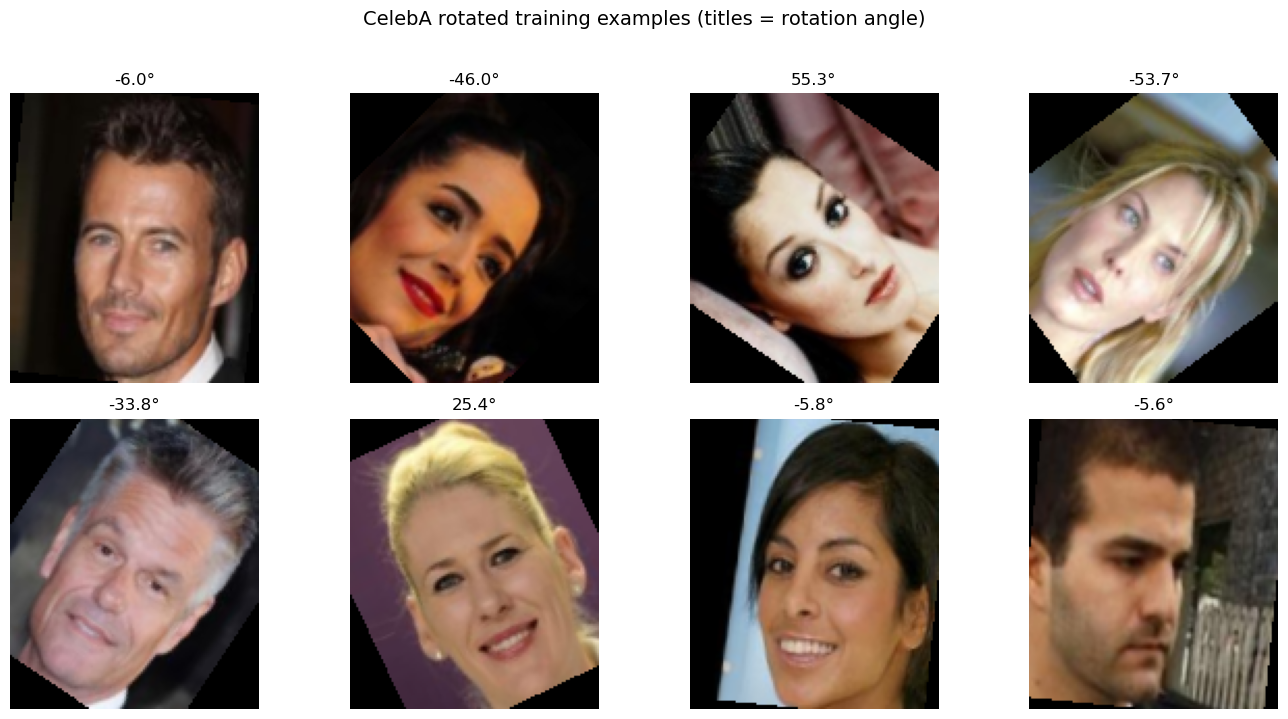

In [13]:
# Plot some celebA images, rotated
# Your code here

# From one batch
x_batch, y_batch = next(iter(train_rot_loader))

n_show = 8
n_show = min(n_show, x_batch.size(0))

ncols = 4
nrows = math.ceil(n_show / ncols)

plt.figure(figsize=(3.5 * ncols, 3.5 * nrows))
for i in range(n_show):
    ax = plt.subplot(nrows, ncols, i + 1)
    show_tensor_image(x_batch[i], title=f"{y_batch[i].item():.1f}°")
plt.suptitle("CelebA rotated training examples (titles = rotation angle)", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

### 2.2 Building and training your CNN

#### 2.2.1 Defining your model
Construct a CNN regressor with multiple convolutional layers (and any other layers you think will help). Display a summary of the model and report the total number of parameters. You do **not** need more than a few million parameters.

**Note:** It is fine to implement a well-known architecture idea (e.g., VGG-style blocks), but you may not import a pre-built model. Build the network layer-by-layer in your own code.

In [14]:
# For context, its a good idea to view the shape of our rotated image batches
xb, yb = next(iter(train_rot_loader))
print("X batch:", xb.shape, "y batch:", yb.shape)

X batch: torch.Size([256, 3, 140, 120]) y batch: torch.Size([256])


In [15]:
# Construct Model
# Your code here

model_CNN_regressor = nn.Sequential(
    # Block 1: 140x120 -> 70x60
    nn.Conv2d(3, 32, kernel_size=3, padding=1, bias=False),
    nn.BatchNorm2d(32),
    nn.ReLU(inplace=True),
    nn.Conv2d(32, 32, kernel_size=3, padding=1, bias=False),
    nn.BatchNorm2d(32),
    nn.ReLU(inplace=True),
    nn.MaxPool2d(2),

    # Block 2: 70x60 -> 35x30
    nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=False),
    nn.BatchNorm2d(64),
    nn.ReLU(inplace=True),
    nn.Conv2d(64, 64, kernel_size=3, padding=1, bias=False),
    nn.BatchNorm2d(64),
    nn.ReLU(inplace=True),
    nn.MaxPool2d(2),

    # Block 3: 35x30 -> 17x15
    nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=False),
    nn.BatchNorm2d(128),
    nn.ReLU(inplace=True),
    nn.Conv2d(128, 128, kernel_size=3, padding=1, bias=False),
    nn.BatchNorm2d(128),
    nn.ReLU(inplace=True),
    nn.MaxPool2d(2),
    nn.Dropout2d(0.05),

    # Block 4: 17x15 -> 8x7
    nn.Conv2d(128, 256, kernel_size=3, padding=1, bias=False),
    nn.BatchNorm2d(256),
    nn.ReLU(inplace=True),
    nn.Conv2d(256, 256, kernel_size=3, padding=1, bias=False),
    nn.BatchNorm2d(256),
    nn.ReLU(inplace=True),
    nn.MaxPool2d(2),
    nn.Dropout2d(0.10),

    # Head: global pool -> MLP -> scalar
    nn.AdaptiveAvgPool2d((1, 1)),  # (B,256,1,1)
    nn.Flatten(),                  # (B,256)
    nn.Linear(256, 128),
    nn.ReLU(inplace=True),
    nn.Dropout(0.20),
    nn.Linear(128, 1),             # (B,1)
    nn.Flatten(),                  # (B,)
).to(DEVICE)


# parameter count check
total_params = sum(p.numel() for p in model_CNN_regressor.parameters())
trainable_params = sum(p.numel() for p in model_CNN_regressor.parameters() if p.requires_grad)
print(f"Total params: {total_params:,} | Trainable params: {trainable_params:,}")


# summary of model layers and types with shapes
def sequential_summary(model: nn.Sequential, input_shape=(3, 140, 120), device=DEVICE):
    model.eval()
    x = torch.zeros((1,) + input_shape, device=device)
    print(f"{'Layer':35s} {'Type':20s} {'Output shape'}")
    print("-"*75)
    with torch.no_grad():
        for i, layer in enumerate(model):
            x = layer(x)
            print(f"{str(i):35s} {layer.__class__.__name__:20s} {tuple(x.shape)}")

sequential_summary(model_CNN_regressor, input_shape=(3, 140, 120), device=DEVICE)

Total params: 1,206,241 | Trainable params: 1,206,241
Layer                               Type                 Output shape
---------------------------------------------------------------------------
0                                   Conv2d               (1, 32, 140, 120)
1                                   BatchNorm2d          (1, 32, 140, 120)
2                                   ReLU                 (1, 32, 140, 120)
3                                   Conv2d               (1, 32, 140, 120)
4                                   BatchNorm2d          (1, 32, 140, 120)
5                                   ReLU                 (1, 32, 140, 120)
6                                   MaxPool2d            (1, 32, 70, 60)
7                                   Conv2d               (1, 64, 70, 60)
8                                   BatchNorm2d          (1, 64, 70, 60)
9                                   ReLU                 (1, 64, 70, 60)
10                                  Conv2d               (

#### 2.2.2 Training and saving your model
Train your rotation-regression model using your rotated CelebA training set and report the loss and MAE (mean absolute error) on the train, validation, and test sets.

You *must* save your best model weights to disk so rerunning the notebook does **not** require retraining but instead loads your trained model from disk.

You may use any reasonable optimizer/scheduler. Report your final train and validation losses.

In [16]:
# Train and save your model
# Evaluate trained model (train / val / test)
# Your code here


# hyperparameters
EPOCHS = 20
LR = 2e-3
WEIGHT_DECAY = 1e-4
PATIENCE = 5
BATCH_SIZE = BATCH_SIZE_ROT

def make_save_path():
    name = (f"model_CNN_regressor_"f"lr{LR}_"f"wd{WEIGHT_DECAY}_"f"bs{BATCH_SIZE}_"f"ep{EPOCHS}.pt_"f"pat{PATIENCE}.pt")
    return Path("saved_models") / name

MODEL_PATH_celebA = make_save_path()
MODEL_PATH_celebA.parent.mkdir(parents=True, exist_ok=True)
HISTORY_PATH_celebA = MODEL_PATH_celebA.with_suffix(".history.pt")

def train_one_epoch_celebA(model, loader, optimizer, loss_fn):
    model.train()
    total_loss = 0.0
    total_abs  = 0.0
    n = 0

    for xb, yb in tqdm(loader, leave=False):
        xb = xb.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        pred = model(xb).squeeze(1)

        loss = loss_fn(pred, yb)
        loss.backward()
        optimizer.step()

        bs = xb.size(0)
        total_loss += loss.item() * bs
        total_abs  += (pred - yb).abs().sum().item()
        n += bs

    return total_loss / n, total_abs / n  # (MSE, MAE)


@torch.no_grad()
def evaluate_celebA(model, loader, loss_fn):
    model.eval()
    total_loss = 0.0
    total_abs  = 0.0
    n = 0

    for xb, yb in loader:
        xb = xb.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True)

        pred = model(xb).squeeze(1)
        loss = loss_fn(pred, yb)

        bs = xb.size(0)
        total_loss += loss.item() * bs
        total_abs  += (pred - yb).abs().sum().item()
        n += bs

    return total_loss / n, total_abs / n  # (MSE, MAE)


loss_fn = nn.MSELoss()
optimizer = torch.optim.AdamW(model_CNN_regressor.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=1)


if MODEL_PATH_celebA.exists() and HISTORY_PATH_celebA.exists() :
    print(f"Loading saved best weights from: {MODEL_PATH_celebA}")
    model_CNN_regressor.load_state_dict(torch.load(MODEL_PATH_celebA, map_location=DEVICE))
    history = torch.load(HISTORY_PATH_celebA)
    print("Loaded saved model + history.")
else:
    print("Training model...")
    history = {"train_loss": [], "train_mae": [], "val_loss": [],   "val_mae": [], "lr": []}
    best_val_loss = float("inf")
    best_epoch = -1
    bad_epochs = 0

    for epoch in range(1, EPOCHS + 1):
        train_loss, train_mae = train_one_epoch_celebA(model_CNN_regressor, train_rot_loader, optimizer, loss_fn)
        val_loss, val_mae     = evaluate_celebA(model_CNN_regressor, val_rot_loader, loss_fn)

        scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["train_mae"].append(train_mae)
        history["val_loss"].append(val_loss)
        history["val_mae"].append(val_mae)
        history["lr"].append(optimizer.param_groups[0]["lr"])

        print(
            f"Epoch {epoch:02d} | "
            f"train MSE {train_loss:.4f}, MAE {train_mae:.2f}° | "
            f"val MSE {val_loss:.4f}, MAE {val_mae:.2f}° | "
            f"lr {optimizer.param_groups[0]['lr']:.2e}"
        )

        # save best
        if val_loss < best_val_loss - 1e-6:
            best_val_loss = val_loss
            best_epoch = epoch
            bad_epochs = 0
            torch.save(model_CNN_regressor.state_dict(), MODEL_PATH_celebA)
            torch.save(history, HISTORY_PATH_celebA)
        else:
            bad_epochs += 1
            if bad_epochs >= PATIENCE:
                print(f"Early stopping. Best epoch was {best_epoch} with val MSE {best_val_loss:.4f}.")
                break

    # Load best weights at end
    print(f"Loading best weights from: {MODEL_PATH_celebA}")
    model_CNN_regressor.load_state_dict(torch.load(MODEL_PATH_celebA, map_location=DEVICE))



# Evaluation
train_loss, train_mae = evaluate_celebA(model_CNN_regressor, train_rot_loader, loss_fn)
val_loss, val_mae     = evaluate_celebA(model_CNN_regressor, val_rot_loader,   loss_fn)
test_loss, test_mae   = evaluate_celebA(model_CNN_regressor, test_rot_loader,  loss_fn)

print("Final results using best saved weights:")
print(f"Train: MSE = {train_loss:.4f} | MAE = {train_mae:.2f}°")
print(f"Val:   MSE = {val_loss:.4f} | MAE = {val_mae:.2f}°")
print(f"Test:  MSE = {test_loss:.4f} | MAE = {test_mae:.2f}°")

Loading saved best weights from: saved_models/model_CNN_regressor_lr0.002_wd0.0001_bs256_ep20.pt_pat5.pt
Loaded saved model + history.
Final results using best saved weights:
Train: MSE = 3.2745 | MAE = 1.25°
Val:   MSE = 4.4635 | MAE = 1.37°
Test:  MSE = 3.5259 | MAE = 1.30°


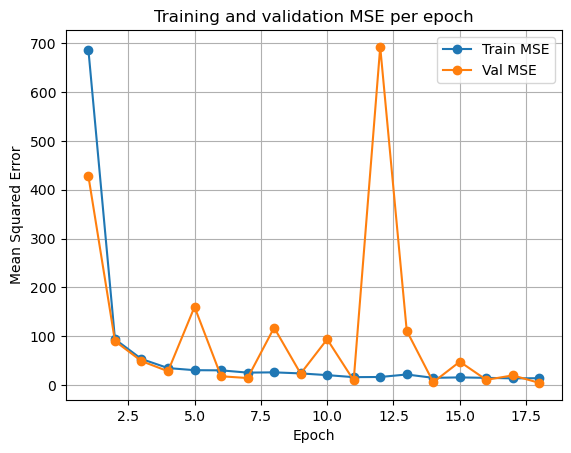

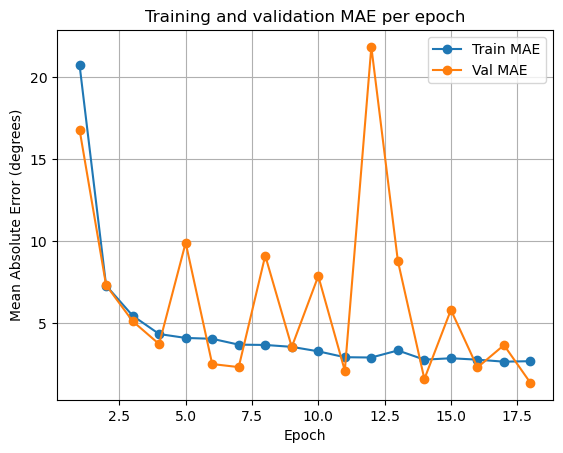

In [17]:
# Plot
epochs = np.arange(1, len(history["train_loss"]) + 1)

# MSE Loss Plot
plt.figure()
plt.plot(epochs, history["train_loss"], marker="o", label="Train MSE")
plt.plot(epochs, history["val_loss"], marker="o", label="Val MSE")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.title("Training and validation MSE per epoch")
plt.legend()
plt.grid(True)
plt.show()


# MAE Plot
plt.figure()
plt.plot(epochs, history["train_mae"], marker="o", label="Train MAE")
plt.plot(epochs, history["val_mae"], marker="o", label="Val MAE")
plt.xlabel("Epoch")
plt.ylabel("Mean Absolute Error (degrees)")
plt.title("Training and validation MAE per epoch")
plt.legend()
plt.grid(True)
plt.show()

<div style="background-color:#e6f2ff; padding:15px; border-radius:8px;">

The model converges rapidly during the early epochs, indicating that global facial orientation cues are quickly learned by the network. Although the validation loss exhibits occasional large spikes, the learning rate scheduler helps stabilize training and allows the model to continue improving after these fluctuations.

The best validation performance is achieved at epoch 18, with a validation MSE of 4.46 and a MAE of 1.37°, demonstrating very high precision in rotation estimation.

The close alignment between train (MAE 1.25°), validation (MAE 1.37°), and test (MAE 1.30°) errors indicates minimal overfitting and strong generalization performance.

</div>

#### 2.2.3 Visual inspection of predictions
Create a subplots grid with **4 rows × 3 columns**. Each row is a separate image from the *test* set, and each column is:

1. Original (rotated) image 
2. Predicted straightened image (rotate by **− predicted angle**) 
3. Target straightened image (rotate by **− true angle**)

Title columns (2) and (3) with the predicted rotation and actual rotation, respectively. Your regressor expects a batch dimension, so be careful about tensor shapes.

In [18]:
# Rotation helpers for visualization (may be useful)
def _unwrap_subset(ds):
    # Handle Subset(Subset(...)) etc.
    while hasattr(ds, "dataset"):
        ds = ds.dataset
    return ds

def rotate_tensor_vis(x, angle_deg, *, norm=None):
    """
    Rotate a single image tensor for visualization.
    - If `norm` is provided (transforms.Normalize), we unnormalize -> rotate -> renormalize.
    - Returns a CPU tensor (good for matplotlib).
    """
    to_pil = transforms.ToPILImage()
    to_tensor = transforms.ToTensor()

    x = x.detach().cpu()

    # If the tensor is normalized, undo it back to [0,1] before converting to PIL
    if norm is not None:
        mean = torch.tensor(norm.mean).view(-1, 1, 1)
        std  = torch.tensor(norm.std).view(-1, 1, 1)
        x01 = x * std + mean
    else:
        x01 = x

    x01 = x01.clamp(0, 1)
    pil = to_pil(x01)
    pil_rot = tvF.rotate(pil, float(angle_deg),
                         interpolation=tvF.InterpolationMode.BILINEAR,
                         fill=0)

    x_rot = to_tensor(pil_rot)

    if norm is not None:
        x_rot = norm(x_rot)

    return x_rot

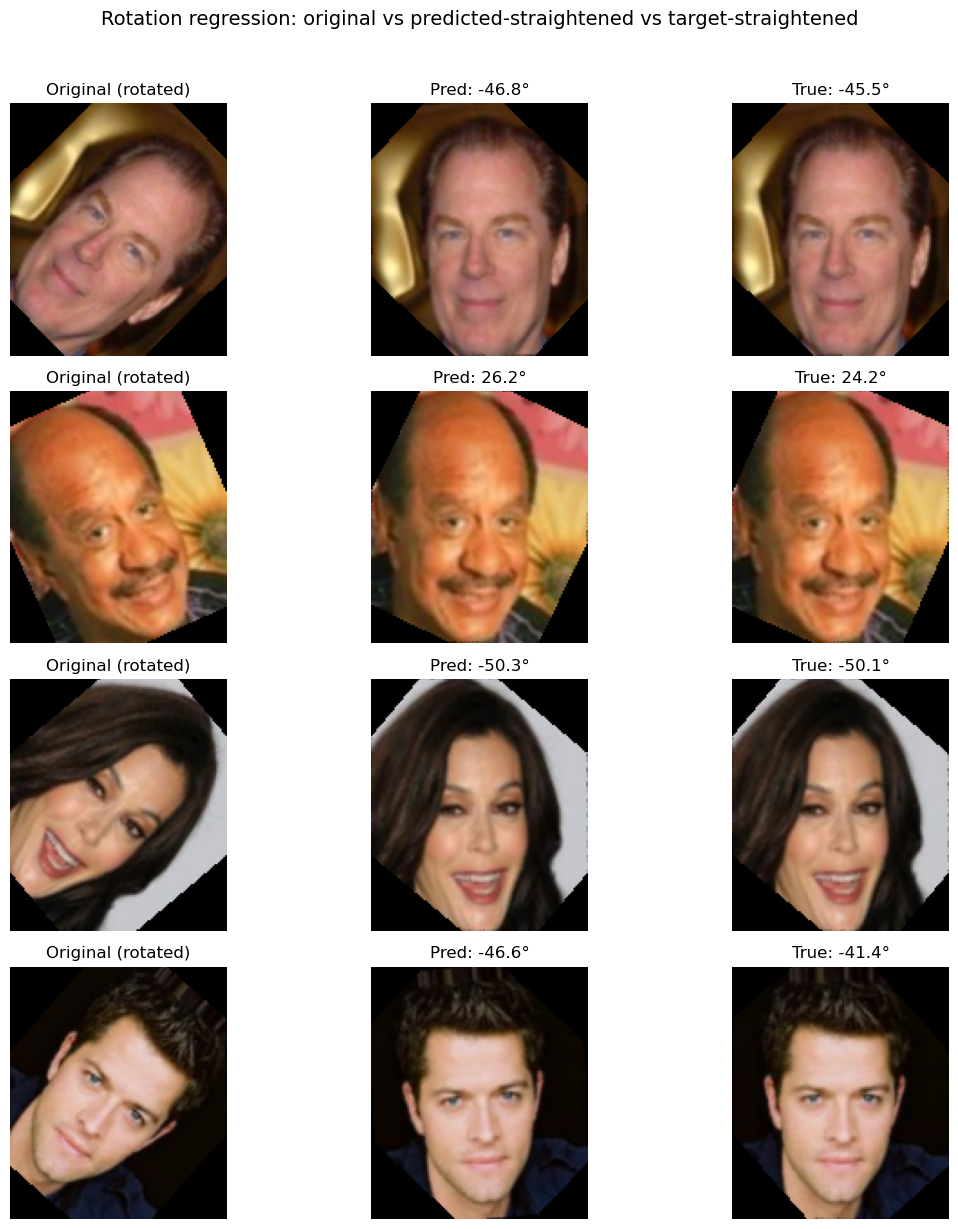

In [19]:
# Visual prediciton insepction
# Your code here


model_CNN_regressor.eval()

# one batch from test loader
xb, yb = next(iter(test_rot_loader))
xb = xb.to(DEVICE)
yb = yb.to(DEVICE)

n_rows = 4
n_rows = min(n_rows, xb.size(0))
idxs = list(range(n_rows))

plt.figure(figsize=(12, 12))

for r, i in enumerate(idxs):
    x_i = xb[i]          # (3,H,W) normalized
    y_true = yb[i].item()

    # regressor expects batch dimension
    with torch.no_grad():
        y_pred = model_CNN_regressor(x_i.unsqueeze(0)).squeeze().item()  # scalar

    # Column 1: Original rotated image (just show x_i)
    ax = plt.subplot(n_rows, 3, r*3 + 1)
    show_tensor_image(x_i, title="Original (rotated)")

    # Column 2: Predicted straightened image (rotate by -pred)
    x_pred_straight = rotate_tensor_vis(x_i, -y_pred, norm=normalize)  # returns normalized tensor
    ax = plt.subplot(n_rows, 3, r*3 + 2)
    show_tensor_image(x_pred_straight, title=f"Pred: {y_pred:.1f}°")

    # Column 3: Target straightened image (rotate by -true)
    x_true_straight = rotate_tensor_vis(x_i, -y_true, norm=normalize)
    ax = plt.subplot(n_rows, 3, r*3 + 3)
    show_tensor_image(x_true_straight, title=f"True: {y_true:.1f}°")

plt.suptitle("Rotation regression: original vs predicted-straightened vs target-straightened", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

<div style="background-color:#e6f2ff; padding:15px; border-radius:8px;">

Visual inspection confirms that predicted straightened images are nearly indistinguishable from target straightened images. This is consistent with the low MAE values reported earlier, showing that the small numerical errors correspond to visually accurate rotation corrections.

</div>

## PART 3: Image Segmentation
### Overview
In this section, we will use the Oxford-IIIT Pet dataset to design a model for an image segmentation task.

[Semantic image segmentation](https://arxiv.org/abs/2302.06378) is a computer vision application where we assign a semantically meaningful label, or class, to every pixel in the image. For example, a camera on a self-driving car would segment the imagery around it into semantic labels such as "Road", "Person", "Bike", etc.

Our dataset contains images of various pet breeds along with their corresponding segmentation masks. Each raw image is 500x403 with three RGB channels, while the corresponding mask is of the same size but contains only a single channel, indicating the pixel class.

For simplicity, we resize both the images and masks to 64x64 to speed up training.
We have also provided all the necessary preprocessing code for you as well as some functions for visualization.

In [20]:
# Oxford-IIIT Pet segmentation dataset (images + trimap masks)

PET_CHECK = Path("oxford-iiit-pet/images")
PET_ROOT, download_pets = shared_or_local(PET_CHECK)
print("Pets root:", PET_ROOT, "| download:", download_pets)

pets_trainval = torchvision.datasets.OxfordIIITPet(
    root=PET_ROOT, split="trainval", target_types="segmentation", download=download_pets
)
pets_test = torchvision.datasets.OxfordIIITPet(
    root=PET_ROOT, split="test", target_types="segmentation", download=download_pets
)

print("trainval:", len(pets_trainval), "| test:", len(pets_test))

Pets root: /shared/courseSharedFolders/163602outer/163602/datasets | download: False
trainval: 3680 | test: 3669


In [21]:
# Preprocessing utilities for images + masks
IMG_SIZE = (64, 64)  # (H, W)

img_tf_pet = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5)),
])

def preprocess_mask(mask_pil, mode: str):
    """Convert the Oxford-IIIT Pet trimap mask into a training target.

    The provided masks are "trimaps" with values {1,2,3}:
      - 1: pet
      - 2: background
      - 3: border/outline (ambiguous)

    Modes:
      - "binary": return {0,1} where 1 = pet, 0 = background (treat border as background)
      - "three_class": return {0,1,2} where 0 = background, 1 = pet, 2 = border
    """
    mode = mode.lower()
    if mode in {"3class", "3-class", "threeclass"}:
        mode = "three_class"

    m = transforms.Resize(IMG_SIZE)(mask_pil)  # keep labels sharp
    m = np.array(m, dtype=np.int64)

    if mode == "binary":
        # pet(1) -> 1.0, everything else -> 0.0
        y = (m == 1).astype(np.float32)
        return torch.from_numpy(y)
    elif mode == "three_class":
        # map {2(background),1(pet),3(border)} -> {0,1,2}
        y = np.zeros_like(m, dtype=np.int64)
        y[m == 1] = 1
        y[m == 3] = 2
        return torch.from_numpy(y)
    else:
        raise ValueError("mode must be 'binary' or 'three_class'")

class PetSegDataset(Dataset):
    """Wrap Oxford-IIIT Pet, returning (image_tensor, mask_tensor)."""
    def __init__(self, base_ds, mode: str = "binary"):
        self.ds = base_ds
        self.mode = mode

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        img, mask = self.ds[idx]  # PIL image + PIL mask
        x = img_tf_pet(img)
        y = preprocess_mask(mask, self.mode)
        return x, y

In [22]:
# Helper code to prepare datasets + loaders for binary segmentation (train/val/test)

pet_full_bin = PetSegDataset(pets_trainval, mode="binary")
pet_test_bin = PetSegDataset(pets_test, mode="binary")

VAL_SIZE = 800
pet_train_bin, pet_val_bin = split_train_val(pet_full_bin, val_size=VAL_SIZE, seed=SEED)

BATCH_PET = 128 if DEVICE.type == "cuda" else 32
train_pet_loader, val_pet_loader, test_pet_loader = make_loaders(
    pet_train_bin, pet_val_bin, pet_test_bin, BATCH_PET, device=DEVICE, num_workers=NUM_WORKERS
)

xb, yb = next(iter(train_pet_loader))
print("pet batch:", xb.shape, yb.shape, "| mask unique:", torch.unique(yb))

pet batch: torch.Size([128, 3, 64, 64]) torch.Size([128, 64, 64]) | mask unique: tensor([0., 1.])


### 3.1 Deep CNN for Image Segmentation
Here you'll design a PyTorch segmentation model (train on **train**, tune on **validation**, and report final performance on **test**) that utilizes convolutional layers and **skip connections**. The model should perform **binary** pixel-wise classification using the provided Oxford-IIIT Pet segmentation masks. Store the trained model in a variable called `model_deepcnn`.

Minimum Requirements:
- A reasonably deep CNN architecture (you should be able to reach >80% validation pixel accuracy with ~90 seconds of training on a GPU).
- Accepts an input size of **64 × 64 × 3** and outputs a **64 × 64** binary mask prediction.
- At least **four skip connections** placed appropriately.
- Uses an appropriate loss function and record its value and average pixel accuracy at each epoch.
- Saves trained model and training history to disk to avoid retraining when notebook is re-run
- Reports final model's loss and accuracy on train, validation, and test.
- Plots loss and accuracy for train and validation data across training epochs.

Here are some of the images and their corresponding segmentation masks. The segmentation mask categorizes each pixel into two classes: "background" or "pet".

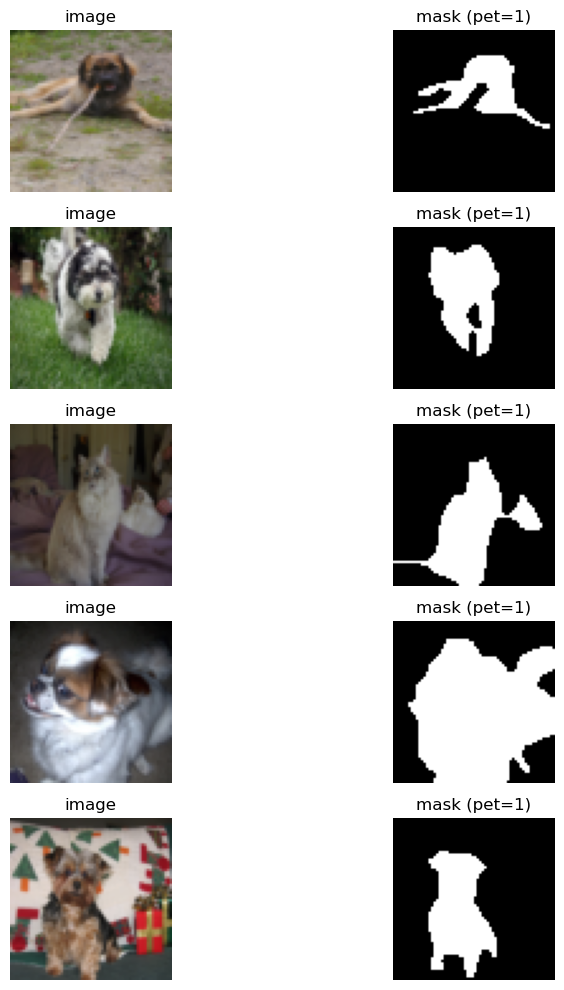

In [23]:
# Helper code to visualize a few training examples (binary masks)
xb, yb = next(iter(train_pet_loader))
n = 5
plt.figure(figsize=(10, 2*n))
for i in range(n):
    img = denorm_01(xb[i].cpu()).permute(1,2,0).numpy()
    msk = yb[i].cpu().numpy()

    plt.subplot(n, 2, 2*i+1)
    plt.imshow(img); plt.axis("off"); plt.title("image")

    plt.subplot(n, 2, 2*i+2)
    plt.imshow(msk, cmap="gray"); plt.axis("off"); plt.title("mask (pet=1)")
plt.tight_layout()
plt.show()

<div style="background-color:#e6f2ff; padding:15px; border-radius:8px;">

The model is a U-Net style CNN made of an encoder, a bottleneck, and a decoder with skip connections. 

The encoder contains four convolutional blocks, each followed by MaxPool2d to progressively reduce the spatial size of the feature maps. The decoder then upsamples the feature maps back to the original image size using ConvTranspose2d layers.

Each convolutional block contains two Conv2d layers with 3×3 kernels, followed by BatchNorm2d and ReLU. The convolutional layers extract spatial features from the images. The first layers learn simple features such as edges and textures, while deeper layers capture more abstract and semantic features of the pets. I used 3×3 kernels because they are standard and work well in CNN architectures.

BatchNorm2d stabilizes training by normalizing activations, which helps gradients flow better and makes convergence faster. ReLU introduces non-linearity so the model can learn complex patterns.

MaxPool2d reduces the spatial resolution at each stage of the encoder. This allows the network to capture larger context while reducing computation. In the bottleneck, the feature maps have the smallest spatial size but the largest number of channels, which helps the network capture global information about the image.

In the decoder, ConvTranspose2d layers increase the spatial resolution step by step. At each stage, the upsampled features are concatenated with the corresponding encoder features through skip connections. These skip connections help preserve spatial details that would otherwise be lost during downsampling, which improves segmentation accuracy.

Finally, a 1×1 convolution layer produces one output channel per pixel, representing the segmentation logits. After applying a sigmoid function, each pixel is classified as either pet or background.

</div>

In [24]:
# Build, train, and evaluate final binary segmentation model
# Your code here


model_deepcnn = nn.Sequential(
    # enc1: 0..5
    nn.Conv2d(3, 32, 3, padding=1, bias=False),
    nn.BatchNorm2d(32),
    nn.ReLU(inplace=True),
    nn.Conv2d(32, 32, 3, padding=1, bias=False),
    nn.BatchNorm2d(32),
    nn.ReLU(inplace=True),
    # pool1: 6
    nn.MaxPool2d(2),

    # enc2: 7..12
    nn.Conv2d(32, 64, 3, padding=1, bias=False),
    nn.BatchNorm2d(64),
    nn.ReLU(inplace=True),
    nn.Conv2d(64, 64, 3, padding=1, bias=False),
    nn.BatchNorm2d(64),
    nn.ReLU(inplace=True),
    # pool2: 13
    nn.MaxPool2d(2),

    # enc3: 14..19
    nn.Conv2d(64, 128, 3, padding=1, bias=False),
    nn.BatchNorm2d(128),
    nn.ReLU(inplace=True),
    nn.Conv2d(128, 128, 3, padding=1, bias=False),
    nn.BatchNorm2d(128),
    nn.ReLU(inplace=True),
    # pool3: 20
    nn.MaxPool2d(2),

    # enc4: 21..26
    nn.Conv2d(128, 256, 3, padding=1, bias=False),
    nn.BatchNorm2d(256),
    nn.ReLU(inplace=True),
    nn.Conv2d(256, 256, 3, padding=1, bias=False),
    nn.BatchNorm2d(256),
    nn.ReLU(inplace=True),
    # pool4: 27
    nn.MaxPool2d(2),

    # bottleneck: 28..33
    nn.Conv2d(256, 512, 3, padding=1, bias=False),
    nn.BatchNorm2d(512),
    nn.ReLU(inplace=True),
    nn.Conv2d(512, 512, 3, padding=1, bias=False),
    nn.BatchNorm2d(512),
    nn.ReLU(inplace=True),

    # up1: 34
    nn.ConvTranspose2d(512, 256, 2, stride=2),
    # dec1: 35..40 
    nn.Conv2d(512, 256, 3, padding=1, bias=False),
    nn.BatchNorm2d(256),
    nn.ReLU(inplace=True),
    nn.Conv2d(256, 256, 3, padding=1, bias=False),
    nn.BatchNorm2d(256),
    nn.ReLU(inplace=True),

    # up2: 41
    nn.ConvTranspose2d(256, 128, 2, stride=2),
    # dec2: 42..47
    nn.Conv2d(256, 128, 3, padding=1, bias=False),
    nn.BatchNorm2d(128),
    nn.ReLU(inplace=True),
    nn.Conv2d(128, 128, 3, padding=1, bias=False),
    nn.BatchNorm2d(128),
    nn.ReLU(inplace=True),

    # up3: 48
    nn.ConvTranspose2d(128, 64, 2, stride=2),
    # dec3: 49..54
    nn.Conv2d(128, 64, 3, padding=1, bias=False),
    nn.BatchNorm2d(64),
    nn.ReLU(inplace=True),
    nn.Conv2d(64, 64, 3, padding=1, bias=False),
    nn.BatchNorm2d(64),
    nn.ReLU(inplace=True),

    # up4: 55
    nn.ConvTranspose2d(64, 32, 2, stride=2),
    # dec4: 56..61
    nn.Conv2d(64, 32, 3, padding=1, bias=False),
    nn.BatchNorm2d(32),
    nn.ReLU(inplace=True),
    nn.Conv2d(32, 32, 3, padding=1, bias=False),
    nn.BatchNorm2d(32),
    nn.ReLU(inplace=True),

    # final: 62 / 1x1 conv -> logits
    nn.Conv2d(32, 1, kernel_size=1),
).to(DEVICE)

def forward_deepcnn(x):
    x1 = model_deepcnn[0:6](x)     # enc1: 0..5
    p1 = model_deepcnn[6](x1)      # pool1: 6

    x2 = model_deepcnn[7:13](p1)   # enc2: 7..12
    p2 = model_deepcnn[13](x2)     # pool2: 13

    x3 = model_deepcnn[14:20](p2)  # enc3: 14..19
    p3 = model_deepcnn[20](x3)     # pool3: 20

    x4 = model_deepcnn[21:27](p3)  # enc4: 21..26
    p4 = model_deepcnn[27](x4)     # pool4: 27

    xb = model_deepcnn[28:34](p4)  # bottleneck: 28..33

    x = model_deepcnn[34](xb)      # up1: 34
    x = model_deepcnn[35:41](torch.cat([x4, x], dim=1))     # dec1: 35..40  # skip 1

    x = model_deepcnn[41](x)       # up2: 41
    x = model_deepcnn[42:48](torch.cat([x3, x], dim=1))     # dec2: 42..47  # skip 2

    x = model_deepcnn[48](x)       # up3: 48
    x = model_deepcnn[49:55](torch.cat([x2, x], dim=1))     # dec3: 49..54  # skip 3

    x = model_deepcnn[55](x)       # up4: 55
    x = model_deepcnn[56:62](torch.cat([x1, x], dim=1))     # dec4: 56..61  # skip 4

    logits = model_deepcnn[62](x)  # final: 62
    return logits

# attach the forward with skips
model_deepcnn.forward = forward_deepcnn



# hyperparameters
EPOCHS = 20
LR = 2e-3
WEIGHT_DECAY = 1e-4
PATIENCE = 5
BATCH_SIZE = BATCH_PET

def make_save_path_pets():
    name = (f"model_deepcnn_"
            f"lr{LR}_wd{WEIGHT_DECAY}_bs{BATCH_SIZE}_ep{EPOCHS}_pat{PATIENCE}.pt")
    return Path("saved_models") / name

MODEL_PATH_DEEPCNN = make_save_path_pets()
MODEL_PATH_DEEPCNN.parent.mkdir(parents=True, exist_ok=True)
HISTORY_PATH_DEEPCNN = MODEL_PATH_DEEPCNN.with_suffix(".history.pt")


def train_one_epoch_deepcnn(model, loader, optimizer, loss_fn):
    model.train()
    total_loss = 0.0
    total_acc  = 0.0
    n = 0

    for xb, yb in tqdm(loader, leave=False):
        xb = xb.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True)  # (B,H,W) float {0,1}

        optimizer.zero_grad(set_to_none=True)
        
        logits = model(xb)  # (B,1,H,W)
        if logits.dim() != 4 or logits.size(1) != 1:
            raise ValueError(f"Expected logits shape (B,1,H,W), got {tuple(logits.shape)}")

        logits_hw = logits[:, 0] # (B,H,W)
        loss = loss_fn(logits_hw, yb)  # (B,H,W) vs (B,H,W)
        loss.backward()
        optimizer.step()

        with torch.no_grad():
            probs = torch.sigmoid(logits_hw)      # (B,H,W) in [0,1]
            pred = (probs > 0.5).float()          # (B,H,W) in {0,1}
            batch_acc = (pred == yb).float().mean().item()

        bs = xb.size(0)
        total_loss += loss.item() * bs
        total_acc  += batch_acc * bs
        n += bs

    return total_loss / n, total_acc / n


@torch.no_grad()
def evaluate_deepcnn(model, loader, loss_fn):
    model.eval()
    total_loss = 0.0
    total_acc  = 0.0
    n = 0

    for xb, yb in loader:
        xb = xb.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True)

        logits = model(xb)
        if logits.dim() != 4 or logits.size(1) != 1:
            raise ValueError(f"Expected logits shape (B,1,H,W), got {tuple(logits.shape)}")

        logits_hw = logits[:, 0]
        loss = loss_fn(logits_hw, yb)

        probs = torch.sigmoid(logits_hw)
        pred = (probs > 0.5).float()
        batch_acc = (pred == yb).float().mean().item()

        bs = xb.size(0)
        total_loss += loss.item() * bs
        total_acc  += batch_acc * bs
        n += bs

    return total_loss / n, total_acc / n



loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model_deepcnn.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=1)


if MODEL_PATH_DEEPCNN.exists() and HISTORY_PATH_DEEPCNN.exists():
    print(f"Loading saved best weights from: {MODEL_PATH_DEEPCNN}")
    model_deepcnn.load_state_dict(torch.load(MODEL_PATH_DEEPCNN, map_location=DEVICE))
    history = torch.load(HISTORY_PATH_DEEPCNN)
    print("Loaded saved model + history.")
else:
    print("Training model...")
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "lr": []}
    best_val_loss = float("inf")
    best_epoch = -1
    bad_epochs = 0

    for epoch in range(1, EPOCHS + 1):
        train_loss, train_acc = train_one_epoch_deepcnn(model_deepcnn, train_pet_loader, optimizer, loss_fn)
        val_loss, val_acc     = evaluate_deepcnn(model_deepcnn, val_pet_loader, loss_fn)

        scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["lr"].append(optimizer.param_groups[0]["lr"])

        print(
            f"Epoch {epoch:02d} | "
            f"train loss {train_loss:.4f}, pix acc {train_acc*100:.2f}% | "
            f"val loss {val_loss:.4f}, pix acc {val_acc*100:.2f}% | "
            f"lr {optimizer.param_groups[0]['lr']:.2e}"
        )

        # save best
        if val_loss < best_val_loss - 1e-6:
            best_val_loss = val_loss
            best_epoch = epoch
            bad_epochs = 0
            torch.save(model_deepcnn.state_dict(), MODEL_PATH_DEEPCNN)
            torch.save(history, HISTORY_PATH_DEEPCNN)
        else:
            bad_epochs += 1
            if bad_epochs >= PATIENCE:
                print(f"Early stopping. Best epoch was {best_epoch} with val loss {best_val_loss:.4f}.")
                break

    print(f"Loading best weights from: {MODEL_PATH_DEEPCNN}")
    model_deepcnn.load_state_dict(torch.load(MODEL_PATH_DEEPCNN, map_location=DEVICE))


# Evaluation
train_loss, train_acc = evaluate_deepcnn(model_deepcnn, train_pet_loader, loss_fn)
val_loss, val_acc     = evaluate_deepcnn(model_deepcnn, val_pet_loader,   loss_fn)
test_loss, test_acc   = evaluate_deepcnn(model_deepcnn, test_pet_loader,  loss_fn)

print("\nFinal results using best saved weights:")
print(f"Train: loss = {train_loss:.4f} | pixel acc = {train_acc*100:.2f}%")
print(f"Val:   loss = {val_loss:.4f} | pixel acc = {val_acc*100:.2f}%")
print(f"Test:  loss = {test_loss:.4f} | pixel acc = {test_acc*100:.2f}%")


Loading saved best weights from: saved_models/model_deepcnn_lr0.002_wd0.0001_bs128_ep20_pat5.pt
Loaded saved model + history.

Final results using best saved weights:
Train: loss = 0.1208 | pixel acc = 95.10%
Val:   loss = 0.1879 | pixel acc = 92.64%
Test:  loss = 0.1991 | pixel acc = 92.13%


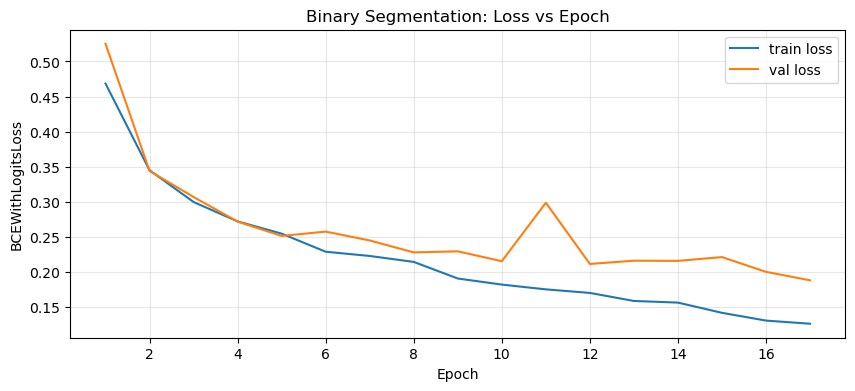

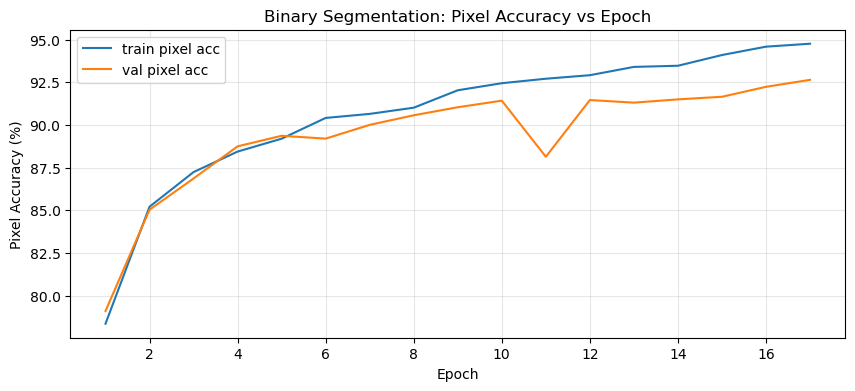

In [25]:
# Plot training curves for binary segmentation
# Your code here

epochs = np.arange(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(10,4))
plt.plot(epochs, history["train_loss"], label="train loss")
plt.plot(epochs, history["val_loss"], label="val loss")
plt.xlabel("Epoch")
plt.ylabel("BCEWithLogitsLoss")
plt.title("Binary Segmentation: Loss vs Epoch")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10,4))
plt.plot(epochs, np.array(history["train_acc"]) * 100, label="train pixel acc")
plt.plot(epochs, np.array(history["val_acc"]) * 100, label="val pixel acc")
plt.xlabel("Epoch")
plt.ylabel("Pixel Accuracy (%)")
plt.title("Binary Segmentation: Pixel Accuracy vs Epoch")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

<div style="background-color:#e6f2ff; padding:15px; border-radius:8px;">
    
The model converges quickly during the first few epochs, as shown by the rapid decrease in training and validation loss and the steady increase in pixel accuracy. This indicates that the network is able to learn meaningful spatial features for segmentation early in training. Although there are a few fluctuations in the validation loss (for example around epoch 11), the learning rate scheduler helps stabilize training and allows performance to continue improving afterward.

The best validation performance is achieved around epoch 17, with a validation loss of 0.1879 and a pixel accuracy of 92.64%, which shows strong segmentation quality. The close alignment between train (95.10%), validation (92.64%), and test (92.13%) pixel accuracy suggests limited overfitting and good generalization to unseen images. Overall, the model achieves high and stable performance on the segmentation task.

</div>

Run the cell below, and you will see your segmentation result. You can run the cell multiple times to see different result sets.

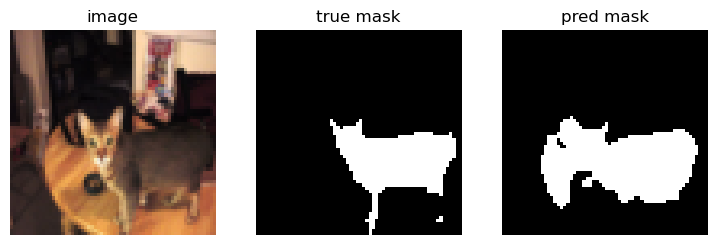

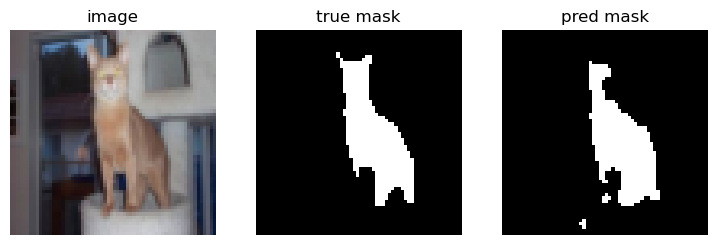

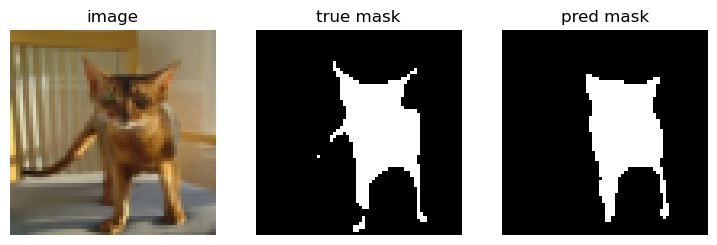

In [26]:
def visualize_predictions_binary(model, loader, n=3):
    """Show image + true mask + predicted mask for a few samples."""
    model.eval()
    xb, yb = next(iter(loader))
    xb, yb = xb.to(DEVICE), yb.to(DEVICE)

    with torch.no_grad():
        logits = model(xb)
        # Accept (B,1,H,W) or (B,H,W)
        if logits.dim() == 4 and logits.size(1) == 1:
            probs = torch.sigmoid(logits[:, 0])
        else:
            probs = torch.sigmoid(logits)
        pred = (probs > 0.5).float()

    xb = xb.cpu()
    yb = yb.cpu()
    pred = pred.cpu()

    for i in range(min(n, xb.size(0))):
        plt.figure(figsize=(9, 3))
        plt.subplot(1, 3, 1); show_tensor_image(xb[i], title="image")
        plt.subplot(1, 3, 2); plt.imshow(yb[i].numpy(), cmap="gray"); plt.axis("off"); plt.title("true mask")
        plt.subplot(1, 3, 3); plt.imshow(pred[i].numpy(), cmap="gray"); plt.axis("off"); plt.title("pred mask")
        plt.show()

visualize_predictions_binary(model_deepcnn, test_pet_loader, n=3)

### 3.2 [209] U-Net for 3-Class Image Segmentation
This question is required for 209 students but optional for others.

Build a **U-Net** style architecture that predicts **3 classes per pixel** for the Oxford-IIIT Pet masks. Use an appropriate multi-class loss (e.g., cross-entropy), and report validation metrics. Store the trained model in a variable called `model_unet`.

As in the previous question, you should save the trained model and training history to disk to avoid retraining when notebook is re-run, reports final model's loss and accuracy on train, validation, and test, and plot loss and accuracy across for train and validation.

In [27]:
# Helper code for three-class segmentation (train/val/test)

pet_full_3c = PetSegDataset(pets_trainval, mode="three_class")
pet_test_3c = PetSegDataset(pets_test, mode="three_class")

VAL_SIZE = 800
pet_train_3c, pet_val_3c = split_train_val(pet_full_3c, val_size=VAL_SIZE, seed=SEED + 1)

BATCH_PET_3C = 128 if DEVICE.type == "cuda" else 32
train_pet_3c_loader, val_pet_3c_loader, test_pet_3c_loader = make_loaders(
    pet_train_3c, pet_val_3c, pet_test_3c, BATCH_PET_3C, device=DEVICE, num_workers=NUM_WORKERS
)

xb3, yb3 = next(iter(train_pet_3c_loader))
print("pet 3c batch:", xb3.shape, yb3.shape, "| mask unique:", torch.unique(yb3))

pet 3c batch: torch.Size([128, 3, 64, 64]) torch.Size([128, 64, 64]) | mask unique: tensor([0, 1, 2])


In [28]:
# Define and train a U-Net for 3-class segmentation
# Your code here


model_unet = nn.Sequential(
    # enc1: 0..5
    nn.Conv2d(3, 32, 3, padding=1, bias=False),
    nn.BatchNorm2d(32),
    nn.ReLU(inplace=True),
    nn.Conv2d(32, 32, 3, padding=1, bias=False),
    nn.BatchNorm2d(32),
    nn.ReLU(inplace=True),
    # pool1: 6
    nn.MaxPool2d(2),

    # enc2: 7..12
    nn.Conv2d(32, 64, 3, padding=1, bias=False),
    nn.BatchNorm2d(64),
    nn.ReLU(inplace=True),
    nn.Conv2d(64, 64, 3, padding=1, bias=False),
    nn.BatchNorm2d(64),
    nn.ReLU(inplace=True),
    # pool2: 13
    nn.MaxPool2d(2),

    # enc3: 14..19
    nn.Conv2d(64, 128, 3, padding=1, bias=False),
    nn.BatchNorm2d(128),
    nn.ReLU(inplace=True),
    nn.Conv2d(128, 128, 3, padding=1, bias=False),
    nn.BatchNorm2d(128),
    nn.ReLU(inplace=True),
    # pool3: 20
    nn.MaxPool2d(2),

    # enc4: 21..26
    nn.Conv2d(128, 256, 3, padding=1, bias=False),
    nn.BatchNorm2d(256),
    nn.ReLU(inplace=True),
    nn.Conv2d(256, 256, 3, padding=1, bias=False),
    nn.BatchNorm2d(256),
    nn.ReLU(inplace=True),
    # pool4: 27
    nn.MaxPool2d(2),

    # bottleneck: 28..33
    nn.Conv2d(256, 512, 3, padding=1, bias=False),
    nn.BatchNorm2d(512),
    nn.ReLU(inplace=True),
    nn.Conv2d(512, 512, 3, padding=1, bias=False),
    nn.BatchNorm2d(512),
    nn.ReLU(inplace=True),

    # up1: 34
    nn.ConvTranspose2d(512, 256, 2, stride=2),
    # dec1: 35..40 
    nn.Conv2d(512, 256, 3, padding=1, bias=False),
    nn.BatchNorm2d(256),
    nn.ReLU(inplace=True),
    nn.Conv2d(256, 256, 3, padding=1, bias=False),
    nn.BatchNorm2d(256),
    nn.ReLU(inplace=True),

    # up2: 41
    nn.ConvTranspose2d(256, 128, 2, stride=2),
    # dec2: 42..47
    nn.Conv2d(256, 128, 3, padding=1, bias=False),
    nn.BatchNorm2d(128),
    nn.ReLU(inplace=True),
    nn.Conv2d(128, 128, 3, padding=1, bias=False),
    nn.BatchNorm2d(128),
    nn.ReLU(inplace=True),

    # up3: 48
    nn.ConvTranspose2d(128, 64, 2, stride=2),
    # dec3: 49..54
    nn.Conv2d(128, 64, 3, padding=1, bias=False),
    nn.BatchNorm2d(64),
    nn.ReLU(inplace=True),
    nn.Conv2d(64, 64, 3, padding=1, bias=False),
    nn.BatchNorm2d(64),
    nn.ReLU(inplace=True),

    # up4: 55
    nn.ConvTranspose2d(64, 32, 2, stride=2),
    # dec4: 56..61
    nn.Conv2d(64, 32, 3, padding=1, bias=False),
    nn.BatchNorm2d(32),
    nn.ReLU(inplace=True),
    nn.Conv2d(32, 32, 3, padding=1, bias=False),
    nn.BatchNorm2d(32),
    nn.ReLU(inplace=True),

    # final: 62 
    nn.Conv2d(32, 3, kernel_size=1), # 3 classe logits
).to(DEVICE)

def forward_unet(x):
    x1 = model_unet[0:6](x)     # enc1: 0..5
    p1 = model_unet[6](x1)      # pool1: 6

    x2 = model_unet[7:13](p1)   # enc2: 7..12
    p2 = model_unet[13](x2)     # pool2: 13

    x3 = model_unet[14:20](p2)  # enc3: 14..19
    p3 = model_unet[20](x3)     # pool3: 20

    x4 = model_unet[21:27](p3)  # enc4: 21..26
    p4 = model_unet[27](x4)     # pool4: 27

    xb = model_unet[28:34](p4)  # bottleneck: 28..33

    x = model_unet[34](xb)      # up1: 34
    x = model_unet[35:41](torch.cat([x4, x], dim=1))     # dec1: 35..40  # skip 1

    x = model_unet[41](x)       # up2: 41
    x = model_unet[42:48](torch.cat([x3, x], dim=1))     # dec2: 42..47  # skip 2

    x = model_unet[48](x)       # up3: 48
    x = model_unet[49:55](torch.cat([x2, x], dim=1))     # dec3: 49..54  # skip 3

    x = model_unet[55](x)       # up4: 55
    x = model_unet[56:62](torch.cat([x1, x], dim=1))     # dec4: 56..61  # skip 4

    logits = model_unet[62](x)  # final: 62
    return logits

# attach the forward with skips
model_unet.forward = forward_unet


# hyperparameters
EPOCHS = 20
LR = 2e-3
WEIGHT_DECAY = 1e-4
PATIENCE = 5
BATCH_SIZE = BATCH_PET_3C

def make_save_path_unet3c():
    name = (f"model_unet3c_"
            f"lr{LR}_wd{WEIGHT_DECAY}_bs{BATCH_SIZE}_ep{EPOCHS}_pat{PATIENCE}.pt")
    return Path("saved_models") / name

MODEL_PATH_UNET = make_save_path_unet3c()
MODEL_PATH_UNET.parent.mkdir(parents=True, exist_ok=True)
HISTORY_PATH_UNET = MODEL_PATH_UNET.with_suffix(".history.pt")


def train_one_epoch_unet3c(model, loader, optimizer, loss_fn):
    model.train()
    total_loss = 0.0
    total_acc  = 0.0
    n = 0

    for xb, yb in tqdm(loader, leave=False):
        xb = xb.to(DEVICE, non_blocking=True)       # (B,3,H,W)
        yb = yb.to(DEVICE, non_blocking=True).long()# (B,H,W) in {0,1,2}

        optimizer.zero_grad(set_to_none=True)

        logits = model(xb)                           # (B,3,H,W)
        if logits.dim() != 4 or logits.size(1) != 3:
            raise ValueError(f"Expected logits shape (B,3,H,W), got {tuple(logits.shape)}")

        loss = loss_fn(logits, yb) # Cross Entropy expects (B,C,H,W) + (B,H,W)
        loss.backward()
        optimizer.step()

        # pixel accuracy
        with torch.no_grad():
            pred = logits.argmax(dim=1)              # (B,H,W)
            batch_acc = (pred == yb).float().mean().item()

        bs = xb.size(0)
        total_loss += loss.item() * bs
        total_acc  += batch_acc * bs
        n += bs

    return total_loss / n, total_acc / n


@torch.no_grad()
def evaluate_unet3c(model, loader, loss_fn):
    model.eval()
    total_loss = 0.0
    total_acc  = 0.0
    n = 0

    for xb, yb in loader:
        xb = xb.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True).long()

        logits = model(xb)                           # (B,3,H,W)
        if logits.dim() != 4 or logits.size(1) != 3:
            raise ValueError(f"Expected logits shape (B,3,H,W), got {tuple(logits.shape)}")

        loss = loss_fn(logits, yb)

        pred = logits.argmax(dim=1)
        batch_acc = (pred == yb).float().mean().item()

        bs = xb.size(0)
        total_loss += loss.item() * bs
        total_acc  += batch_acc * bs
        n += bs

    return total_loss / n, total_acc / n


loss_fn = nn.CrossEntropyLoss() # Cross Entropy heer
optimizer = torch.optim.AdamW(model_unet.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=1)


if MODEL_PATH_UNET.exists() and HISTORY_PATH_UNET.exists():
    print(f"Loading saved best weights from: {MODEL_PATH_UNET}")
    model_unet.load_state_dict(torch.load(MODEL_PATH_UNET, map_location=DEVICE))
    history = torch.load(HISTORY_PATH_UNET)
    print("Loaded saved model + history.")
else:
    print("Training model_unet (3-class)...")
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "lr": []}
    best_val_loss = float("inf")
    best_epoch = -1
    bad_epochs = 0

    for epoch in range(1, EPOCHS + 1):
        train_loss, train_acc = train_one_epoch_unet3c(model_unet, train_pet_3c_loader, optimizer, loss_fn)
        val_loss, val_acc     = evaluate_unet3c(model_unet, val_pet_3c_loader, loss_fn)

        scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["lr"].append(optimizer.param_groups[0]["lr"])

        print(
            f"Epoch {epoch:02d} | "
            f"train loss {train_loss:.4f}, pix acc {train_acc*100:.2f}% | "
            f"val loss {val_loss:.4f}, pix acc {val_acc*100:.2f}% | "
            f"lr {optimizer.param_groups[0]['lr']:.2e}"
        )

        if val_loss < best_val_loss - 1e-6:
            best_val_loss = val_loss
            best_epoch = epoch
            bad_epochs = 0
            torch.save(model_unet.state_dict(), MODEL_PATH_UNET)
            torch.save(history, HISTORY_PATH_UNET)
        else:
            bad_epochs += 1
            if bad_epochs >= PATIENCE:
                print(f"Early stopping. Best epoch was {best_epoch} with val loss {best_val_loss:.4f}.")
                break

    print(f"Loading best weights from: {MODEL_PATH_UNET}")
    model_unet.load_state_dict(torch.load(MODEL_PATH_UNET, map_location=DEVICE))


# Final evaluation
train_loss, train_acc = evaluate_unet3c(model_unet, train_pet_3c_loader, loss_fn)
val_loss, val_acc     = evaluate_unet3c(model_unet, val_pet_3c_loader,   loss_fn)
test_loss, test_acc   = evaluate_unet3c(model_unet, test_pet_3c_loader,  loss_fn)

print("\nFinal results using best saved weights:")
print(f"Train: loss = {train_loss:.4f} | pixel acc = {train_acc*100:.2f}%")
print(f"Val:   loss = {val_loss:.4f} | pixel acc = {val_acc*100:.2f}%")
print(f"Test:  loss = {test_loss:.4f} | pixel acc = {test_acc*100:.2f}%")


Loading saved best weights from: saved_models/model_unet3c_lr0.002_wd0.0001_bs128_ep20_pat5.pt
Loaded saved model + history.

Final results using best saved weights:
Train: loss = 0.2299 | pixel acc = 90.83%
Val:   loss = 0.3471 | pixel acc = 87.18%
Test:  loss = 0.3544 | pixel acc = 87.09%


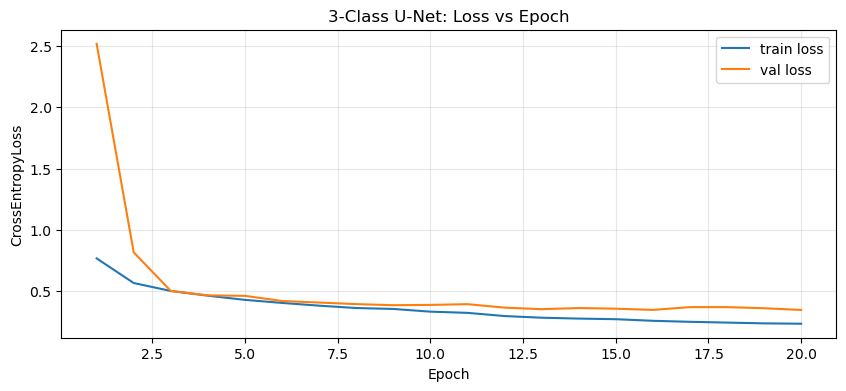

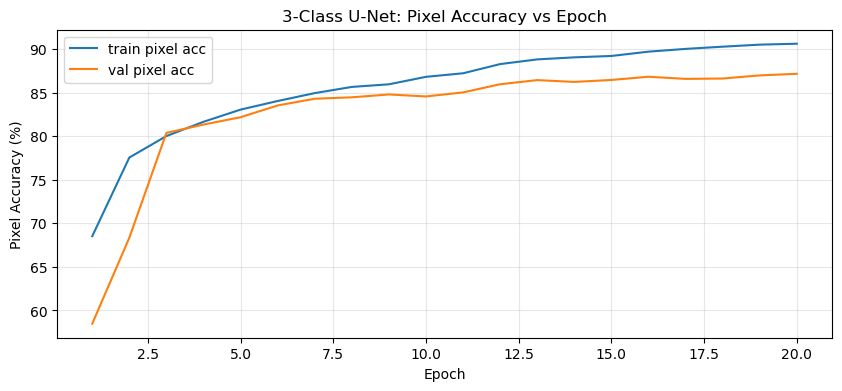

In [29]:
# Plot training curves for U-Net (if trained this run)

epochs = np.arange(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(10,4))
plt.plot(epochs, history["train_loss"], label="train loss")
plt.plot(epochs, history["val_loss"], label="val loss")
plt.xlabel("Epoch"); plt.ylabel("CrossEntropyLoss")
plt.title("3-Class U-Net: Loss vs Epoch")
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10,4))
plt.plot(epochs, np.array(history["train_acc"]) * 100, label="train pixel acc")
plt.plot(epochs, np.array(history["val_acc"]) * 100, label="val pixel acc")
plt.xlabel("Epoch"); plt.ylabel("Pixel Accuracy (%)")
plt.title("3-Class U-Net: Pixel Accuracy vs Epoch")
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

<div style="background-color:#e6f2ff; padding:15px; border-radius:8px;">
    
The model shows steady convergence throughout training, with both training and validation loss decreasing consistently and pixel accuracy improving over epochs. The large validation loss at epoch 1 suggests that multi-class segmentation is initially harder to learn than the binary case, but performance stabilizes quickly after a few epochs. The learning rate scheduler helps refine the model in later stages, leading to gradual improvements in validation accuracy.

The best validation performance is achieved near the end of training, with a validation loss of 0.3471 and a pixel accuracy of 87.18%. The close alignment between train (90.83%), validation (87.18%), and test (87.09%) accuracy indicates good generalization and limited overfitting. As expected, the overall accuracy is lower than in the binary case, since predicting three classes per pixel is a more challenging task, especially for thin border regions.

</div>

Run the cell below to visualize segmentation predictions from your 3-class model. Re-run to view different batches.

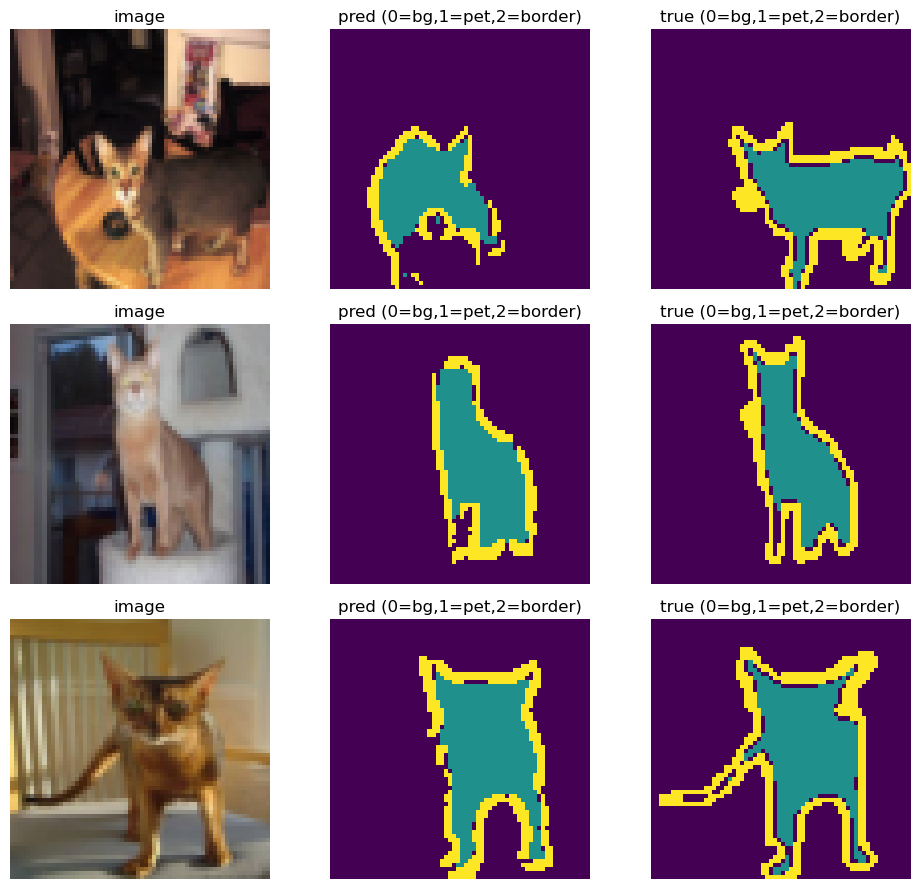

In [30]:
# Run to visualize U-Net predictions
def visualize_predictions_3class(model: nn.Module, loader: DataLoader, n: int = 3):
    model.eval()
    xb, yb = next(iter(loader))
    xb = xb[:n].to(DEVICE)
    yb = yb[:n]

    with torch.no_grad():
        logits = model(xb).cpu()
        pred = logits.argmax(dim=1)

    plt.figure(figsize=(10, 3*n))
    for i in range(n):
        img = denorm_01(xb[i].cpu()).permute(1,2,0).numpy()
        true = yb[i].numpy()
        pr = pred[i].numpy()

        plt.subplot(n, 3, 3*i+1)
        plt.imshow(img); plt.axis("off"); plt.title("image")

        plt.subplot(n, 3, 3*i+2)
        plt.imshow(pr, vmin=0, vmax=2); plt.axis("off"); plt.title("pred (0=bg,1=pet,2=border)")

        plt.subplot(n, 3, 3*i+3)
        plt.imshow(true, vmin=0, vmax=2); plt.axis("off"); plt.title("true (0=bg,1=pet,2=border)")
    plt.tight_layout()
    plt.show()
    
visualize_predictions_3class(model_unet, test_pet_3c_loader, n=3)

## Wrap-up
* In a few sentences, please describe the aspect(s) of the assignment you found most challenging. This could be conceptual and/or related to coding and implementation.

* How many hours did you spend working on this assignment? Store this as an int or float in `hours_spent_on_hw`. If you worked on the project in a group, report the *average* time spent per person.

<div style="background-color:#e6f2ff; padding:15px; border-radius:8px;">
Conceptually, I found this assignment more difficult than the first one because we started working with more complex networks, especially the U-Net structure, which is not easy to implement. Handling the skip connections and making sure all the tensor dimensions matched correctly in the forward pass was probably the most challenging part.

However, in terms of time spent, I gained a lot of time compared to the previous homework. Using the Harvard on-demand environment was much more efficient than Google Colab, which I struggled with last time. Also, saving the model weights made re-running the notebook much faster, which helped a lot.

Overall, there was less implementation struggle and more focus on building complex and interesting networks, which made the assignment fun to do. I did miss the Kaggle competition part a bit, since trying many different architectures to improve performance last time was something I really enjoyed.

</div>

In [31]:
hours_spent_on_hw = 15

In [32]:
assert float(hours_spent_on_hw),\
    "Please select a time in hours (int or float) to specify how long you spent on this assignment."

In [33]:
time_end = time.time()
print(f"It took {(time_end - time_start)/60:.2f} minutes for this notebook to run")

It took 4.11 minutes for this notebook to run


**This concludes HW2. Thank you!**